# 24 · E1k: does the slow current help the *linear* model too, and does the black box win on wild type?

**Where Notebook 23 left off.** With `L1s` (L1 plus one global slow current) on the ladder, E1's verdict is **unchanged**: sufficiency L\* = L1, necessity L_needed = L0, and calibrated v4 L_closed = L0 for every δ.

| held-out FEVE, both strains | L0 | L1 | **L1s** | L2 | L3 | L4 | B |
|---|---|---|---|---|---|---|---|
| | 0.295 | 0.298 | **0.323** | 0.310 | 0.301 | 0.304 | −0.464 |

* `L1s` is the best rung and clearly beats L1: +0.025 [+0.015, +0.039].
* It does **not** reliably beat the wiring-only **L0**: +0.028 [−0.043, +0.103]. The interval is wide because the linear and the nonlinear models err on different stimuli.

**Two questions follow.**

**1 · Does the slow current help L0 too?** The slow current improved the mechanistic L1. If it improves the *linear* L0 as well (`L0s`, 2 more parameters), then slow dynamics are needed independently of any nonlinear mechanism. Placed on the ladder right after L0, `L0s` could move the necessity and v4 decisions from L0 to L0s, a change in E1's closed level that `L1s` could not produce. As in Notebook 22:
* the slow current is chosen on training pairs from a grid;
* it is then fitted for the same number of steps as a re-fitted L0 control.

**2 · Does the black box win on wild type?** Notebook 23's WT-only rows revealed something E1 never reported. Over both strains the black box B scores −0.46, the reason Notebook 04 called it "overfitting". On **WT pairs alone it scores 0.327, above every rung** (L1s 0.294, L0 0.288, L1 0.268). The black box fails only on unc-31, the strain it sees through a single flag.

If B beats the closed level on WT by more than E1's margin, that is E1's **outcome C** signature for wild type: the activity is predictable, but the ladder does not capture what predicts it. This notebook applies E1's black-box rule to WT pairs.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, pickle, time, datetime, numpy as np, matplotlib.pyplot as plt, jax, jax.numpy as jnp
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:3]) >= (0, 20, 0), \
    f"Notebook 24 needs closurebench >= 0.20.0 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import data as D, ladder as lad, metrics as M_
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
N_BOOT, THRESHOLD = 2000, 0.05
TAG = "" if MODE == "full" else f"_{MODE}"
E1_TAG = "_laptop" if MODE == "smoke" else TAG
LADDER0 = ("L0", "L1", "L2", "L3", "L4"); LADDER2 = ("L0", "L0s", "L1", "L1s", "L2", "L3", "L4")
CONF = {"smoke": dict(STEPS=20), "laptop": dict(STEPS=300), "full": dict(STEPS=1000)}[MODE]; globals().update(CONF)
RHO_G, TAU_G = (0.05, 0.1, 0.15, 0.2, 0.3), (2.0, 5.0, 10.0, 20.0)
try:
    e1_result = json.load(open(os.path.join(RESULTS, f"E1_result{E1_TAG}.json")))
    c = json.load(open(os.path.join(RESULTS, e1_result["preregistration"])))["config"]
    ds = D.Dataset.load(os.path.join(RESULTS, "atlas_dataset.npz"))
    if c["n_neurons"] < ds.N:
        mk = ds.mask()[0]; score = mk.sum(1).astype(float); score[ds.stim] += mk.sum(0)
        ds = D.subset(ds, np.sort(np.argsort(-score)[:c["n_neurons"]]))
    st = lad.Structure.from_dataset(ds, tie=c["tie_classes"]); cfg = lad.SimConfig(**c["sim"])
    folds = M_.kfold_pairs(ds, c["k_folds"], c["fold_seed"])
    PRED = {k: v for k, v in np.load(os.path.join(RESULTS, f"E1_heldout_predictions{E1_TAG}.npz")).items()}
    ck1 = os.path.join(RESULTS, f"e1_checkpoints{E1_TAG}")
    E1_MODELS = [pickle.load(open(os.path.join(ck1, f"fold{f}_L1_final.pkl"), "rb"))["params"] for f in range(c["k_folds"])]
    L0_MODELS = [pickle.load(open(os.path.join(ck1, f"fold{f}_L0_final.pkl"), "rb"))["params"] for f in range(c["k_folds"])]
    LR = float(c.get("lr", 1e-2))
    CK22 = os.path.join(RESULTS, "e1i_ck", "laptop" if MODE == "smoke" else MODE)
    L1S = [pickle.load(open(os.path.join(CK22, f"fold{f}_L1s_sel.pkl"), "rb")) for f in range(c["k_folds"])]
    L1R = [pickle.load(open(os.path.join(CK22, f"fold{f}_L1_refit.pkl"), "rb")) for f in range(c["k_folds"])]
    d9 = os.path.join(RESULTS, f"E1e_result{E1_TAG}.json")
    DELTA = json.load(open(d9))["delta"] if os.path.exists(d9) else {}
    SOURCE = f"E1 ({E1_TAG.strip('_') or 'full'}) + Notebook 22 fits"
except (FileNotFoundError, KeyError) as err:
    if MODE != "smoke":
        raise
    print("E1 / Notebook 22 results not found (", err, ") -> CODE-PATH TEST ONLY on a synthetic worm with made-up rung predictions")
    ds, p_true, R = lad.make_synthetic(lad.random_wiring(N=30, S=12, seed=1), true_level="L1", seed=1)
    st = lad.Structure.from_dataset(ds); cfg = lad.SimConfig(); folds = M_.kfold_pairs(ds, 3, 0)
    rng = np.random.default_rng(0); R = np.asarray(R)
    PRED = {L: R + rng.normal(size=R.shape) * s * R.std() for L, s in zip(LADDER0 + ("B",), (0.6, 0.5, 0.55, 0.6, 0.6, 0.9))}
    E1_MODELS = L1S = L1R = None; DELTA = {"repeat": 0.01}; SOURCE = "synthetic (code path only)"; LR = 1e-2
    L0_MODELS = [lad.init_params("L0", st, jax.random.PRNGKey(f)) for f in range(3)]
print(f"source: {SOURCE} | {ds.N} neurons, {ds.S} stimuli, strains {ds.strains} | E1 rungs {sorted(PRED)} | calibrated deltas {DELTA}")

source: E1 (laptop) + Notebook 22 fits | 120 neurons, 120 stimuli, strains ('wt', 'unc31') | E1 rungs ['B', 'L0', 'L1', 'L2', 'L3', 'L4'] | calibrated deltas {'repeat': 0.0, 'long': 0.0025557642078298222}


### Pre-registration (before §1)

Recorded in `results/E1k_preregistration*.json`. Folds, metric and bootstrap are E1's (as in Notebook 23).
* `L0s` is selected on each fold's training pairs (WT FEVE, as for `L1s`) from a grid of ρ ∈ {0.05, …, 0.3} and τ_n ∈ {2, 5, 10, 20} s.
* It is then fitted for `STEPS` steps from the E1 L0 fit; `L0_refit` gets the same budget.

The rules:
* **SLOW_HELPS_L0:** `L0s` beats `L0_refit` on held-out pairs (both strains), CI lower bound > 0.
* **CLOSED_LEVEL_CHANGES:** on the ladder L0, L0s, L1, L1s, L2, L3, L4 (both strains), at least one of E1's three decisions differs from E1's original.
* **OUTCOME_C_WT:** on WT pairs, E1's black-box rule holds, i.e. the 2.5th percentile of FEVE(B) − FEVE(L\*) is > 0.05, with L\* the WT sufficiency decision on the extended ladder.
* Reported:
  * B − best rung (per bootstrap draw) on WT, with its CI;
  * B's FEVE per strain;
  * the decisions with L0 replaced by `L0_refit`.

In [3]:
prereg = os.path.join(RESULTS, f"E1k_preregistration{TAG}.json")
plan = {"experiment": "E1k slow current on L0; black box on WT", "mode": MODE, "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "source": SOURCE, "ladder": list(LADDER2), "grid": {"rho": list(RHO_G), "tau_n": list(TAU_G)}, "steps": STEPS, "n_boot": N_BOOT,
        "SLOW_HELPS_L0": "L0s beats L0_refit (both strains), CI lower bound > 0",
        "CLOSED_LEVEL_CHANGES": "any E1 decision on the extended ladder differs from E1's original (both strains)",
        "OUTCOME_C_WT": "on WT pairs, 2.5th percentile of FEVE(B) - FEVE(L*) > 0.05 (L* = WT sufficiency decision, extended ladder)"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E1k_preregistration_laptop.json


## 1 · `L0s`: select on training pairs, then fit (checkpointed)

In [4]:
CK = os.path.join(RESULTS, "e1k_ck", MODE); os.makedirs(CK, exist_ok=True)
def split(f):
    test = folds[f]; train = np.zeros_like(test)
    for g in range(len(folds)):
        if g != f: train |= folds[g]
    return train, test
def l0s_init(p, rho, tau_n):
    q = lad.extend_params(jax.tree_util.tree_map(jnp.asarray, p), "L0s", st, jax.random.PRNGKey(0))
    q["rho_s"] = jnp.array(float(np.log(rho / (0.9 - rho)))); q["tau_ns"] = jnp.array(lad.inv_sp(max(tau_n - lad.TAU_MIN, 0.05)))
    return q
def full_pred(level, p):
    return np.asarray(lad.predict(level, jax.tree_util.tree_map(jnp.asarray, p), st, ds.stim, ds.strains, cfg, np.arange(ds.S)))
L0S, L0R, SEL = [], [], {}
for f in range(len(folds)):
    train, _ = split(f)
    ck = os.path.join(CK, f"fold{f}.pkl")
    if os.path.exists(ck):
        d = pickle.load(open(ck, "rb")); L0S.append(d["L0s"]); L0R.append(d["L0_refit"]); SEL[f] = d["sel"]; continue
    t0 = time.time()
    tr = {(r, t): M_.feve(full_pred("L0s", l0s_init(L0_MODELS[f], r, t)), ds, strain="wt", extra_mask=train) for r in RHO_G for t in TAU_G}
    tr0 = M_.feve(full_pred("L0", L0_MODELS[f]), ds, strain="wt", extra_mask=train)
    best = max(tr, key=tr.get); SEL[f] = (best, float(tr[best] - tr0))
    ps, _ = lad.fit("L0s", ds, train_mask=train & ds.mask(), init=l0s_init(L0_MODELS[f], *best), steps=STEPS, lr=LR, verbose=0, st=st, cfg=cfg)
    pr, _ = lad.fit("L0", ds, train_mask=train & ds.mask(), init=jax.tree_util.tree_map(jnp.asarray, L0_MODELS[f]), steps=STEPS, lr=LR, verbose=0, st=st, cfg=cfg)
    ps = jax.tree_util.tree_map(np.asarray, ps); pr = jax.tree_util.tree_map(np.asarray, pr)
    pickle.dump({"L0s": ps, "L0_refit": pr, "sel": SEL[f]}, open(ck, "wb")); L0S.append(ps); L0R.append(pr)
    print(f"fold {f}: grid choice rho {best[0]}, tau_n {best[1]} s (training WT FEVE {SEL[f][1]:+.4f} over L0); after fitting rho "
          f"{0.9 / (1 + np.exp(-ps['rho_s'])):.3f}, tau_n {lad.TAU_MIN + np.log1p(np.exp(ps['tau_ns'])):.1f} s  ({time.time() - t0:.0f} s)", flush=True)
def cv_from(models_by_fold, level):
    out = np.zeros(ds.mean.shape[:3])
    for f, pp in enumerate(models_by_fold):
        out[folds[f]] = full_pred(level, pp)[folds[f]]
    return out
PRED["L0s"] = cv_from(L0S, "L0s"); PRED["L0_refit"] = cv_from(L0R, "L0")
if L1S is not None:
    PRED["L1s"] = cv_from(L1S, "L1s")
else:
    PRED["L1s"] = PRED["L1"] * 1.05
print("predictions assembled for", sorted(PRED))

fold 0: grid choice rho 0.1, tau_n 10.0 s (training WT FEVE +0.0635 over L0); after fitting rho 0.100, tau_n 10.0 s  (83 s)
fold 1: grid choice rho 0.1, tau_n 5.0 s (training WT FEVE +0.0559 over L0); after fitting rho 0.098, tau_n 5.0 s  (75 s)
fold 2: grid choice rho 0.1, tau_n 10.0 s (training WT FEVE +0.0561 over L0); after fitting rho 0.100, tau_n 10.1 s  (86 s)
fold 3: grid choice rho 0.1, tau_n 10.0 s (training WT FEVE +0.0588 over L0); after fitting rho 0.100, tau_n 10.1 s  (73 s)
fold 4: grid choice rho 0.1, tau_n 10.0 s (training WT FEVE +0.0705 over L0); after fitting rho 0.100, tau_n 10.0 s  (74 s)
predictions assembled for ['B', 'L0', 'L0_refit', 'L0s', 'L1', 'L1s', 'L2', 'L3', 'L4']


## 2 · E1's decisions on the extended ladder (both strains)

In [5]:
def decide(ladder, strain=None, swap=None):
    swap = swap or {}
    preds = {L: PRED[swap.get(L, L)] for L in ladder + ("B",)}
    point, boots = M_.bootstrap_feve(preds, ds, list(ladder) + ["B"], n_boot=N_BOOT, seed=0, strain=strain)
    suff = M_.closure_decision(point, boots, ladder=ladder, threshold=THRESHOLD, blackbox="B")
    nec = M_.necessity(point, boots, ladder=ladder)
    v4 = {"delta=0": M_.calibrated_closure(boots, 0.0, ladder)["L_closed"]}
    v4.update({f"delta[{k}]={d:.3f}": M_.calibrated_closure(boots, d, ladder)["L_closed"] for k, d in DELTA.items()})
    return dict(point=point, boots=boots, L_star=suff["L_star"], L_needed=nec["L_needed"], v4=v4, nec=nec, suff=suff)
RES = {"original": decide(LADDER0), "extended": decide(LADDER2), "extended_refitL0": decide(LADDER2, swap={"L0": "L0_refit"}),
       "original_wt": decide(LADDER0, "wt"), "extended_wt": decide(LADDER2, "wt")}
for k, r in RES.items():
    lad_ = LADDER2 if "extended" in k else LADDER0
    print(f"{k:17s}: FEVE " + " ".join(f"{L}={r['point'][L]:.3f}" for L in lad_ + ('B',)))
    print(f"{'':17s}  L* = {r['L_star']} | L_needed = {r['L_needed']} | v4 = {r['v4']}")
print(); print(M_.format_necessity(RES["extended"]["nec"]))
b = RES["extended"]["boots"]; pt = RES["extended"]["point"]
pt_l0, bt_l0 = M_.bootstrap_feve({"L0s": PRED["L0s"], "L0_refit": PRED["L0_refit"]}, ds, ["L0s", "L0_refit"], n_boot=N_BOOT, seed=0)
d = bt_l0["L0s"] - bt_l0["L0_refit"]; g_l0 = float(pt_l0["L0s"] - pt_l0["L0_refit"]); ci_l0 = np.percentile(d, [2.5, 97.5])
print(f"\nL0s - L0_refit (both strains): {g_l0:+.4f}  95% CI [{ci_l0[0]:+.4f}, {ci_l0[1]:+.4f}]")
for x, y in (("L0s", "L0"), ("L1s", "L0s"), ("L1s", "L0")):
    dd = b[x] - b[y]; lo, hi = np.percentile(dd, [2.5, 97.5]); print(f"  {x} - {y}: {pt[x] - pt[y]:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]")
SLOW_HELPS_L0 = bool(ci_l0[0] > 0)
CHANGES = {"L_star": (RES["original"]["L_star"], RES["extended"]["L_star"]), "L_needed": (RES["original"]["L_needed"], RES["extended"]["L_needed"])}
CHANGES.update({f"v4 {k}": (RES["original"]["v4"][k], RES["extended"]["v4"][k]) for k in RES["original"]["v4"]})
CLOSED_LEVEL_CHANGES = any(a != b_ for a, b_ in CHANGES.values())
print("\ndecisions (original -> extended):", CHANGES)
print("Registered rules -> SLOW_HELPS_L0:", SLOW_HELPS_L0, "| CLOSED_LEVEL_CHANGES:", CLOSED_LEVEL_CHANGES)

original         : FEVE L0=0.295 L1=0.298 L2=0.310 L3=0.301 L4=0.304 B=-0.464
                   L* = L1 | L_needed = L0 | v4 = {'delta=0': 'L0', 'delta[repeat]=0.000': 'L0', 'delta[long]=0.003': 'L0'}
extended         : FEVE L0=0.295 L0s=0.364 L1=0.298 L1s=0.323 L2=0.310 L3=0.301 L4=0.304 B=-0.464
                   L* = L0s | L_needed = L0s | v4 = {'delta=0': 'L0s', 'delta[repeat]=0.000': 'L0s', 'delta[long]=0.003': 'L0s'}
extended_refitL0 : FEVE L0=0.375 L0s=0.364 L1=0.298 L1s=0.323 L2=0.310 L3=0.301 L4=0.304 B=-0.464
                   L* = L0 | L_needed = L0 | v4 = {'delta=0': 'L0', 'delta[repeat]=0.000': 'L0', 'delta[long]=0.003': 'L0'}
original_wt      : FEVE L0=0.288 L1=0.268 L2=0.275 L3=0.288 L4=0.292 B=0.327
                   L* = L1 | L_needed = L0 | v4 = {'delta=0': 'L0', 'delta[repeat]=0.000': 'L0', 'delta[long]=0.003': 'L0'}
extended_wt      : FEVE L0=0.288 L0s=0.343 L1=0.268 L1s=0.294 L2=0.275 L3=0.288 L4=0.292 B=0.327
                   L* = L0s | L_needed = L0s | v4 =

## 3 · The black box on wild type (OUTCOME_C_WT)

WT: L* = L0s; FEVE(B) - FEVE(L*) = -0.0158  95% CI [-0.0590, +0.0245] (rule: lower bound > 0.05)
WT: FEVE(B) - best rung (per bootstrap draw) = -0.0168  95% CI [-0.0590, +0.0231]
  strain wt    : B +0.327 | L1s +0.294 | L0 +0.288
  strain unc31 : B -2.149 | L1s +0.383 | L0 +0.310
Registered rule -> OUTCOME_C_WT: False


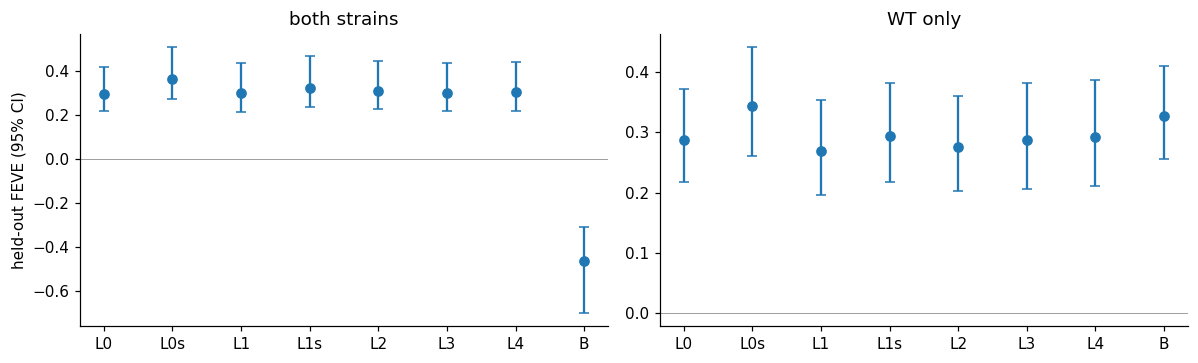

In [6]:
w = RES["extended_wt"]; bw, pw = w["boots"], w["point"]
Lstar_wt = w["L_star"]
if Lstar_wt is not None:
    dB = bw["B"] - bw[Lstar_wt]; loB, hiB = np.percentile(dB, [2.5, 97.5])
    OUTCOME_C_WT = bool(loB > THRESHOLD)
    print(f"WT: L* = {Lstar_wt}; FEVE(B) - FEVE(L*) = {pw['B'] - pw[Lstar_wt]:+.4f}  95% CI [{loB:+.4f}, {hiB:+.4f}] (rule: lower bound > {THRESHOLD})")
else:
    OUTCOME_C_WT = False; print("WT: no sufficiency L* -> E1's black-box rule does not apply")
best = np.max(np.stack([bw[L] for L in LADDER2]), axis=0)
dbest = bw["B"] - best; lo2, hi2 = np.percentile(dbest, [2.5, 97.5])
print(f"WT: FEVE(B) - best rung (per bootstrap draw) = {np.mean(dbest):+.4f}  95% CI [{lo2:+.4f}, {hi2:+.4f}]")
for s in ds.strains:
    pB = M_.bootstrap_feve({"B": PRED["B"], "L1s": PRED["L1s"], "L0": PRED["L0"]}, ds, ["B", "L1s", "L0"], n_boot=200, seed=0, strain=s)[0]
    print(f"  strain {s:6s}: B {pB['B']:+.3f} | L1s {pB['L1s']:+.3f} | L0 {pB['L0']:+.3f}")
print("Registered rule -> OUTCOME_C_WT:", OUTCOME_C_WT)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), sharey=False)
for a, key, title in ((ax[0], "extended", "both strains"), (ax[1], "extended_wt", "WT only")):
    r = RES[key]; lab = list(LADDER2) + ["B"]
    mu = [r["point"][L] for L in lab]; lo = [np.percentile(r["boots"][L], 2.5) for L in lab]; hi = [np.percentile(r["boots"][L], 97.5) for L in lab]
    a.errorbar(range(len(lab)), mu, yerr=[np.subtract(mu, lo), np.subtract(hi, mu)], fmt="o", capsize=3)
    a.set_xticks(range(len(lab))); a.set_xticklabels(lab); a.set_title(title); a.axhline(0, c="0.6", lw=0.6)
ax[0].set_ylabel("held-out FEVE (95% CI)"); plt.tight_layout(); plt.show()

In [7]:
out = {"source": SOURCE, "SLOW_HELPS_L0": SLOW_HELPS_L0, "CLOSED_LEVEL_CHANGES": CLOSED_LEVEL_CHANGES, "OUTCOME_C_WT": OUTCOME_C_WT,
       "L0s_minus_L0refit": {"point": g_l0, "ci": list(ci_l0)}, "changes": CHANGES, "selection": {str(f): v for f, v in SEL.items()},
       "decisions": {k: {"feve": {L: float(v) for L, v in r["point"].items()}, "L_star": r["L_star"], "L_needed": r["L_needed"], "v4": r["v4"]} for k, r in RES.items()},
       "B_minus_best_wt": {"point": float(np.mean(dbest)), "ci": [float(lo2), float(hi2)]}}
json.dump(out, open(os.path.join(RESULTS, f"E1k_result{TAG}.json"), "w"), indent=2, default=float)
print("saved", f"E1k_result{TAG}.json")

saved E1k_result_laptop.json


## Results (laptop mode, run on the M1 Mac)

**Selection and fit of `L0s`.** On every fold the training-pair grid chose ρ = 0.1, with τ_n = 10 s (fold 1: 5 s). The training-WT gain over E1's L0 was +0.056 to +0.071. Fitting for 300 more steps left ρ and τ_n where the grid put them.

**E1's decisions on the extended ladder (both strains, held-out FEVE)**

| | L0 | **L0s** | L1 | L1s | L2 | L3 | L4 | B | L\* | L_needed | v4 (all δ) |
|---|---|---|---|---|---|---|---|---|---|---|---|
| original ladder | 0.295 | – | 0.298 | – | 0.310 | 0.301 | 0.304 | −0.464 | L1 | L0 | L0 |
| extended ladder | 0.295 | **0.364** | 0.298 | 0.323 | 0.310 | 0.301 | 0.304 | −0.464 | **L0s** | **L0s** | **L0s** |
| extended, L0 → `L0_refit` | **0.375** | 0.364 | 0.298 | 0.323 | 0.310 | 0.301 | 0.304 | −0.464 | L0 | L0 | L0 |

* Necessity on the extended ladder: L0s +0.069 [+0.048, +0.096] needed. Every deeper rung is **worse** than the best shallower one: L1 −0.065, L1s −0.040, L2 −0.056, L3 −0.064, L4 −0.060.
* **`L0s − L0_refit` = −0.012 [−0.022, −0.003]** → **SLOW_HELPS_L0 = False**. The slow current is slightly *worse* than simply training L0 for the same 300 extra steps.
* `L1s − L0s` = −0.041 [−0.121, +0.029].
* Registered rule **CLOSED_LEVEL_CHANGES = True** (every decision moved from L0/L1 to L0s). However, the change disappears as soon as E1's L0 is replaced by `L0_refit`: every decision returns to **L0**, and sufficiency also moves from L1 to L0.

**The black box on wild type**

| WT pairs | L0 | L0s | L1 | L1s | L2 | L3 | L4 | B |
|---|---|---|---|---|---|---|---|---|
| held-out FEVE | 0.288 | **0.343** | 0.268 | 0.294 | 0.275 | 0.288 | 0.292 | 0.327 |

* WT L\* = L0s; **FEVE(B) − FEVE(L\*) = −0.016 [−0.059, +0.025]** → **OUTCOME_C_WT = False**. B − best rung per draw: −0.017 [−0.059, +0.023].
* Per strain: WT B 0.327, L1s 0.294, L0 0.288; unc-31 B **−2.149**, L1s 0.383, L0 0.310. B's poor both-strain score is entirely its unc-31 failure.

**What this means.**
1. **E1's L0 was under-fitted, and this is the main finding.** In E1, L0 had the same total budget (1000 steps), but from a single start: no restarts, while L1 got 3. Only 300 more steps from its E1 fit raise its held-out FEVE from 0.295 to **0.375 (+0.080)**. The same treatment gave L1 only +0.004 (Notebook 22). The best predictor found so far is the **linear wiring model**: it beats every mechanistic rung and the black box.
2. **The slow current is not needed by L0.** Its +0.069 over E1's L0 is the under-fit, not a mechanism; against a properly trained L0 it loses 0.012. The "slow process" reading of the first table row is therefore rejected, even though the registered CLOSED_LEVEL_CHANGES flag fired. The reading table below gets a row for this case.
3. **E1's closed level stays L0, and is reinforced.** With a fair L0 even E1's sufficiency rule lands on L0 instead of L1.
4. **The black box has no outcome C on WT.** Its WT lead over the E1 rungs (Notebook 23) is gone once L0 is fitted as well as the others: B 0.327 vs L0s 0.343, and `L0_refit` (WT not printed here; Notebook 25 reports it) scores higher still on both strains.
5. **But E1's rung-to-rung comparisons reflect unequal fit quality.** If 300 steps move L0 by 0.08, the gaps between L1–L4 (≤ 0.012) and between rungs and B cannot be read as differences of mechanism until every rung has been refined the same way and shown to be converged. **Notebook 25 (E1l)** does this: an equal-budget refinement of every rung (L0, L0s, L1, L1s, L2, L3, L4, B), a convergence check (a second round), and then E1's three rules again.

> **Follow-up (Notebook 25).** Point 5 is settled: with every rung refined equally, the verdict is L0 under every rule. A second round raises L0 further, to 0.421, and leaves `L0s` no better (−0.005 [−0.011, −0.000]). Meanwhile L2–L4 and B lose held-out accuracy while gaining on training pairs, which is over-fitting.

## 4 · Reading the result

| SLOW_HELPS_L0 | CLOSED_LEVEL_CHANGES | reading |
|---|---|---|
| yes | yes (to L0s) | **Slow dynamics are required** even by the linear wiring model. The closed level is "wiring + signs + one slow process", the first mechanism E1 positively requires, independent of the static nonlinearity. Confirm with new data (5-s pulses). |
| yes | no | The slow current helps both models, but the gains are too small or too variable across stimuli to move E1's rules at this data size. |
| no | no | The slow current helps only the nonlinear L1. L0's own time constant already does the work, and E1's verdict stands. |
| no | yes (to L0s) | **← observed.** Not anticipated when registering. The decisions move only because E1's own L0 was under-fitted: `L0s` beats E1's L0 but loses to `L0_refit`, and with `L0_refit` every decision returns to L0. E1's verdict stands and is reinforced. The ladder needs an equal-budget refit (Notebook 25). |

| OUTCOME_C_WT | reading |
|---|---|
| yes | On wild type, the activity is **predictable but not closed within the ladder**: a black box with no mechanism beats every mechanistic rung by more than E1's margin. Something systematic is missed, and the least-explained neurons (pharyngeal, gas-sensing; Notebook 04) are where to look. |
| no | **← observed.** B's WT advantage is within E1's margin: no outcome C. It even falls behind `L0s` (−0.016 [−0.059, +0.025]) once L0 is fitted as well as the other rungs. |

**Limits.**
* As in Notebook 23, the slow current was proposed after seeing held-out data.
* B was trained on both strains; its unc-31 failure may simply reflect a single strain flag that cannot extrapolate.